[Batch GD] Test RMSE = 5.0048

Saved loss curve to loss_curve.png

=== RMSE Comparison ===
Method                 Test RMSE
Batch GD                  5.0048
Mini-batch GD             5.0056
sklearn LinearReg         5.0048


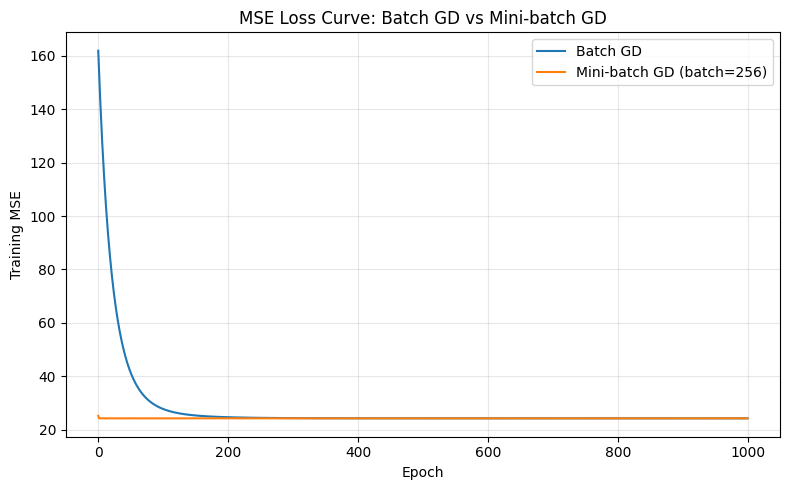

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# The file appears to be in the Colab environment's root directory.
df = pd.read_csv('/placement_predict_50k Dataset.csv')

# Placeholder for FEATURES; replace with actual column names from your dataset
FEATURES = ['CGPA', 'Hostel', 'HistoryOfBacklogs', 'AptitudeTestScore'] # Example features

TARGET = "Salary Package"

data = df[FEATURES + [TARGET]].copy()

# Separate numerical and categorical features for appropriate imputation
numerical_features = ['CGPA', 'AptitudeTestScore']
categorical_features = ['Hostel', 'HistoryOfBacklogs']

# Impute numerical features with median
for col in numerical_features:
    data[col] = data[col].fillna(data[col].median())

# Impute categorical features with mode
for col in categorical_features:
    data[col] = data[col].fillna(data[col].mode()[0])

# Convert categorical features to numerical using one-hot encoding
data = pd.get_dummies(data, columns=categorical_features, drop_first=True)

# Update FEATURES list to reflect the new dummy variables
# Assuming 'Yes' is encoded to 1 and 'No' to 0, the new columns will be 'Hostel_Yes', 'HistoryOfBacklogs_Yes'
FEATURES = ['CGPA', 'AptitudeTestScore', 'Hostel_Yes', 'HistoryOfBacklogs_Yes']

X = data[FEATURES].values
y = data[TARGET].values.reshape(-1, 1)

# Added test_size and random_state parameters
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

n_samples, n_features = X_train_s.shape

X_train_b = np.hstack([
    np.ones((n_samples, 1)),
    X_train_s
])

X_test_b = np.hstack([
    np.ones((X_test_s.shape[0], 1)),
    X_test_s
])


def compute_mse(X, y, theta):
    preds = X @ theta
    errors = preds - y
    return np.mean(errors ** 2)


def batch_gradient_descent(X, y, lr, n_epochs):
    m, n = X.shape

    theta = np.zeros((n, 1))
    loss_history = []

    for epoch in range(n_epochs):
        preds = X @ theta
        errors = preds - y

        gradient = (2 / m) * (X.T @ errors)

        theta -= lr * gradient

        loss_history.append(
            compute_mse(X, y, theta)
        )

    return theta, loss_history


# Provided concrete arguments for batch_gradient_descent
theta_gd, loss_history_gd = batch_gradient_descent(X_train_b, y_train, lr=0.01, n_epochs=1000)

rmse_gd = np.sqrt(
    compute_mse(X_test_b, y_test, theta_gd)
)

print(f"[Batch GD] Test RMSE = {rmse_gd:.4f}")


sk_model = LinearRegression()

sk_model.fit(X_train_s, y_train)

y_pred_sk = sk_model.predict(X_test_s)

rmse_sklearn = np.sqrt(
    mean_squared_error(y_test, y_pred_sk)
)


def mini_batch_gradient_descent(X, y, lr, n_epochs, batch_size, seed):
    m, n = X.shape
    theta = np.zeros((n, 1))
    loss_history = []
    rng = np.random.default_rng(seed)

    for epoch in range(n_epochs):
        indices = rng.permutation(m)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(0, m, batch_size):
            start = i
            end = min(i + batch_size, m);
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            preds = X_batch @ theta
            errors = preds - y_batch

            gradient = (2 / X_batch.shape[0]) * (
                X_batch.T @ errors
            )

            theta -= lr * gradient

        # Append loss after each epoch
        loss_history.append(
            compute_mse(X, y, theta)
        )

    return theta, loss_history


# Provided concrete arguments for mini_batch_gradient_descent
theta_mb, loss_history_mb = mini_batch_gradient_descent(X_train_b, y_train, lr=0.01, n_epochs=1000, batch_size=256, seed=42)

rmse_mb = np.sqrt(
    compute_mse(X_test_b, y_test, theta_mb)
)


plt.figure(figsize=(8, 5))

plt.plot(
    loss_history_gd,
    label="Batch GD"
)

plt.plot(
    loss_history_mb,
    label="Mini-batch GD (batch=256)"
)

plt.xlabel("Epoch")
plt.ylabel("Training MSE")

plt.title(
    "MSE Loss Curve: Batch GD vs Mini-batch GD"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "loss_curve.png",
    dpi=150
)

print("\nSaved loss curve to loss_curve.png")

print("\n=== RMSE Comparison ===")

print(
    f"{'Method':<20}{'Test RMSE':>12}"
)

print(
    f"{'Batch GD':<20}{rmse_gd:>12.4f}"
)

print(
    f"{'Mini-batch GD':<20}{rmse_mb:>12.4f}"
)

print(
    f"{'sklearn LinearReg':<20}{rmse_sklearn:>12.4f}"
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')